<a href="https://colab.research.google.com/github/amyashima27-ops/C-lculo.Num-rico/blob/main/Ativ2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Amanda Miho Yashima

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def simular(dt, tipo=np.float32, passos=2000, pontos=21):

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Condição inicial
    u = np.zeros(pontos, dtype=tipo)

    # Parede inferior em movimento
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]

    falha = None

    with np.errstate(over="raise", invalid="raise"):

        for passo in range(1, passos + 1):

            try:

                novo = u.copy()

                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:]
                        - dois * u[1:-1]
                        + u[:-2]
                    )
                )

            except FloatingPointError as erro:

                falha = passo

                print(
                    f"Falha: tipo={tipo.__name__}, "
                    f"dt={dt}, passo={passo}, "
                    f"tempo={passo * dt:.6f} s"
                )

                break

            u = novo

            tempos.append(passo * dt)

            maximos.append(
                float(np.max(np.abs(u)))
            )

    if falha is None:

        print(
            f"Sem overflow: tipo={tipo.__name__}, "
            f"dt={dt}, passos={passos}"
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
        "dy": dy
    }

In [6]:
H = 0.01
nu = 1e-4
pontos = 21

dy = H / (pontos - 1)

dt_max = dy**2 / (2 * nu)

dt_A = 0.001
dt_B = 0.002

r_A = nu * dt_A / dy**2
r_B = nu * dt_B / dy**2

print("QUESTÃO 1")
print("-----------------------------")
print(f"dy = {dy} m")
print(f"dt_max = {dt_max} s")
print(f"Caso A: r = {r_A}")
print(f"Caso B: r = {r_B}")

QUESTÃO 1
-----------------------------
dy = 0.0005 m
dt_max = 0.0012499999999999998 s
Caso A: r = 0.4000000000000001
Caso B: r = 0.8000000000000002


O caso A será e deu como estável já que o valor de r é menor que 0,5. Já o B é instável por r=0,8 ser maior que 0,5.

---



Sem overflow: tipo=float32, dt=0.001, passos=2000
Falha: tipo=float32, dt=0.002, passo=121, tempo=0.242000 s
Sem overflow: tipo=float64, dt=0.001, passos=2000
Falha: tipo=float64, dt=0.002, passo=917, tempo=1.834000 s
Tipo       dt         r          Falha      Passo     
float32    0.001      0.4000     None       -         
float32    0.002      0.8000     121        121       
float64    0.001      0.4000     None       -         
float64    0.002      0.8000     917        917       


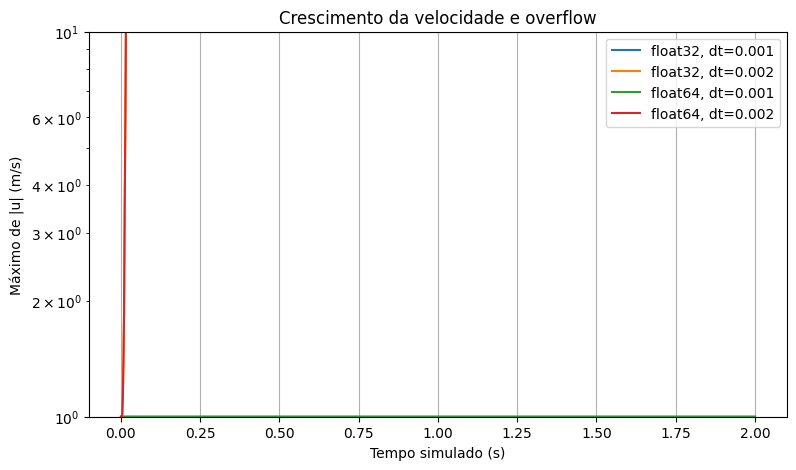

In [7]:
resultados = {}

for tipo in (np.float32, np.float64):

    for dt in (dt_A, dt_B):

        nome = f"{tipo.__name__}, dt={dt}"

        resultados[nome] = simular(
            dt=dt,
            tipo=tipo,
            passos=2000,
            pontos=21
        )

print(
    f"{'Tipo':<10} "
    f"{'dt':<10} "
    f"{'r':<10} "
    f"{'Falha':<10} "
    f"{'Passo':<10}"
)

for nome, resultado in resultados.items():

    tipo, dt_texto = nome.split(", dt=")

    dt = float(dt_texto)

    falha = resultado["falha"]

    if falha is None:
        passo = "-"
    else:
        passo = falha

    print(
        f"{tipo:<10} "
        f"{dt:<10} "
        f"{resultado['r']:<10.4f} "
        f"{str(falha):<10} "
        f"{str(passo):<10}"
    )

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():

    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s)")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()

plt.show()

3.
A solução obtida no caso instável não representa o comportamento físico esperado porque a velocidade deveria ser transmitida gradualmente da placa móvel para o interior do fluido. Como a velocidade da placa é 1,m/s, a solução física deve permanecer entre (0) e (1m/s).No caso instável, com r=0,8, o esquema numérico permite o crescimento de oscilações. Isso ocorre porque o coeficiente central da atualização, (1-2r), torna-se negativo. Consequentemente, pequenos erros numéricos podem ser amplificados a cada passo de tempo. Assim, a velocidade calculada passa a apresentar valores muito superiores aos fisicamente possíveis. O overflow ocorre posteriormente, quando esses valores ultrapassam a capacidade de representação do tipo numérico. Portanto, uma solução pode estar numericamente incorreta antes de ocorrer o overflow.

4.
A utilização de float64 não elimina a instabilidade numérica. Tanto float32 quanto float64 apresentam r=0,8 quando ∆t=0,002s, portanto ambos utilizam um passo de tempo acima do limite de estabilidade do método.A diferença está na capacidade de representação dos números. O float32 possui maior valor finito aproximadamente igual a 3,4x10^38, enquanto o float64 pode representar valores de aproximadamente 1,8x10^308. Por esse motivo, a simulação com float64 suporta o crescimento dos valores por um número maior de passos antes de ocorrer o overflow. Entretanto, a solução já está instável e fisicamente incorreta antes do overflow.Portanto, aumentar a precisão numérica pode atrasar o overflow, mas não corrige a causa da instabilidade. A correção deve ser feita utilizando um passo de tempo que satisfaça a condição de estabilidade.

Novo dy = 0.00025 m
Novo dt_max = 0.00031249999999999995 s
dt = 0.001 s -> r = 1.6000000000000003
dt = 0.0003 s -> r = 0.48
Falha: tipo=float32, dt=0.001, passo=56, tempo=0.056000 s
Sem overflow: tipo=float64, dt=0.0003, passos=2000


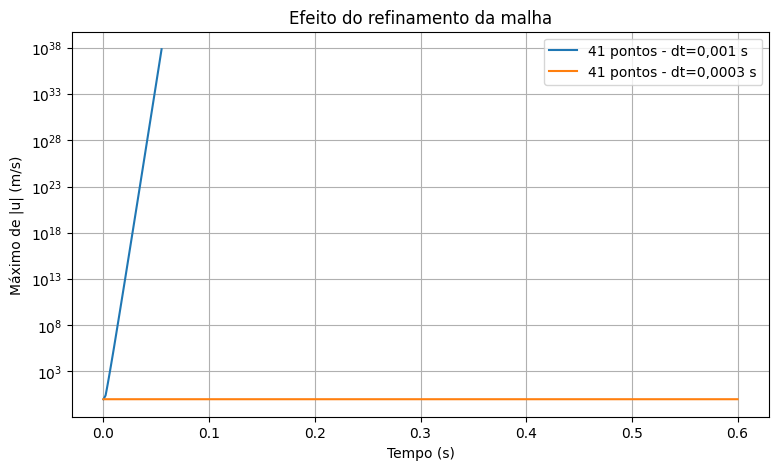

In [9]:
pontos_41 = 41

dy_41 = H / (pontos_41 - 1)

dt_max_41 = dy_41**2 / (2 * nu)

dt_instavel_41 = 0.001

r_instavel_41 = (
    nu * dt_instavel_41 / dy_41**2
)

dt_estavel_41 = 0.0003

r_estavel_41 = (
    nu * dt_estavel_41 / dy_41**2
)

print(f"Novo dy = {dy_41} m")
print(f"Novo dt_max = {dt_max_41} s")
print(f"dt = 0.001 s -> r = {r_instavel_41}")
print(f"dt = 0.0003 s -> r = {r_estavel_41}")


# Teste instável
resultado_41_instavel = simular(
    dt=dt_instavel_41,
    tipo=np.float32,
    passos=2000,
    pontos=41
)


# Teste estável
resultado_41_estavel = simular(
    dt=dt_estavel_41,
    tipo=np.float64,
    passos=2000,
    pontos=41
)

plt.figure(figsize=(9, 5))

plt.semilogy(
    resultado_41_instavel["tempos"],
    resultado_41_instavel["maximos"],
    label="41 pontos - dt=0,001 s"
)

plt.semilogy(
    resultado_41_estavel["tempos"],
    resultado_41_estavel["maximos"],
    label="41 pontos - dt=0,0003 s"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Máximo de |u| (m/s)")
plt.title("Efeito do refinamento da malha")
plt.grid(True)
plt.legend()

plt.show()

5.
Ao aumentar o número de pontos de 21 para 41, o espaçamento da malha diminuiu de 0,0005m para 0,00025m. Com a nova malha, o limite de estabilidade passou a ser ∆t(max)=0,0003125s. Portanto, manter  ∆t=0,001s tornou o método instável, pois nesse caso r=1,6, valor muito superior ao limite r=0,5. Para corrigir a instabilidade, foi escolhido  ∆t=0,0003s. Nesse caso, obteve-se r=0,48, que satisfaz a condição de estabilidade. O resultado mostra que o refinamento da malha, apesar de aumentar a resolução espacial, exige um passo de tempo menor para que o método permaneça estável. Portanto, não é possível refinar a malha mantendo arbitrariamente o mesmo passo de tempo.

Sem overflow: tipo=float64, dt=0.0003, passos=10000

QUESTÃO 6
-----------------------------
r = 0.48
Tempo final = 2.9999999999999996 s
E_inf = 8.781864124784988e-14


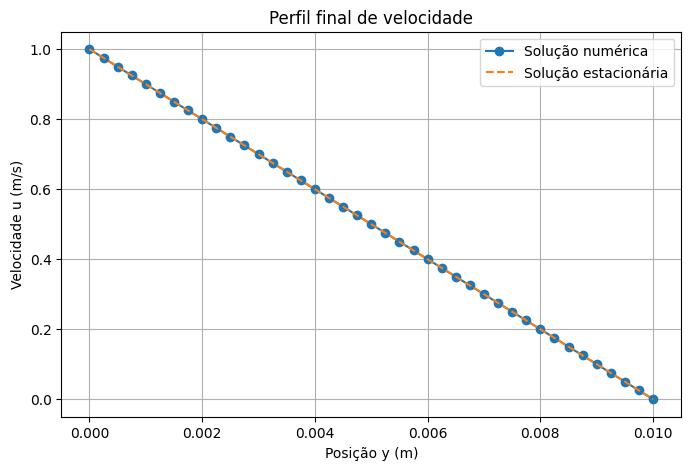

In [10]:
resultado_final = simular(
    dt=0.0003,
    tipo=np.float64,
    passos=10000,
    pontos=41
)

y = resultado_final["y"]
u_numerica = resultado_final["u"]

u_estacionaria = 1 - y / H

erro = np.max(
    np.abs(
        u_numerica - u_estacionaria
    )
)

print("\nQUESTÃO 6")
print("-----------------------------")
print(f"r = {resultado_final['r']}")
print(f"Tempo final = {10000 * 0.0003} s")
print(f"E_inf = {erro}")


plt.figure(figsize=(8, 5))

plt.plot(
    y,
    u_numerica,
    "o-",
    label="Solução numérica"
)

plt.plot(
    y,
    u_estacionaria,
    "--",
    label="Solução estacionária"
)

plt.xlabel("Posição y (m)")
plt.ylabel("Velocidade u (m/s)")
plt.title("Perfil final de velocidade")
plt.grid(True)
plt.legend()

plt.show()

6.
Foi realizada uma simulação estável utilizando 41 pontos, ∆t=0,0003s, float64 e 10.000 passos, correspondendo a um tempo simulado de aproximadamente 3s.

O perfil numérico foi comparado com a solução estacionária

$$
u_{est}(y)=U\left(1-\frac{y}{H}\right).
$$

Após tempo suficiente, a solução numérica se aproxima do perfil estacionário linear, que apresenta velocidade de 1m/s junto à placa móvel e 0m/s junto à placa fixa. A diferença máxima foi de 8.781864124784988e-14, indicando que foi realizado com uma exelente aproximação. É importante destacar que a expressão utilizada para comparação representa o regime estacionário. Durante o início da simulação existe um período transiente no qual o perfil ainda está evoluindo.


7.
A atividade permitiu analisar a relação entre estabilidade numérica, passo de tempo, refinamento da malha e overflow em uma simulação de difusão de velocidade. Para a malha com 21 pontos, foi obtido ∆y=0,0005m e o limite de estabilidade foi ∆t(max)=0,00125s. Dessa forma, o caso com  ∆t=0,001s apresentou r=0,4 e permaneceu estável, enquanto o caso com ∆t=0,002s apresentou r=0,8 e tornou-se instável.A instabilidade provocou crescimento não físico das velocidades e, posteriormente, overflow. A utilização de float64 atrasou a ocorrência do overflow em relação ao float32, devido à maior faixa de representação numérica, mas não eliminou a instabilidade.
No refinamento da malha para 41 pontos, o espaçamento diminuiu para 0,00025m e o novo limite de estabilidade passou a ser 0,0003125s. Assim, manter ∆t=0,001s produziu r=1,6 e tornou o método instável. A utilização de ∆t=0,0003s, resultando em r=0,48, corrigiu a instabilidade.
Portanto, a alteração que efetivamente corrigiu a causa da falha foi a redução do passo de tempo de acordo com o novo limite de estabilidade. O uso de maior precisão numérica pode apenas atrasar o overflow, enquanto a escolha adequada de ∆t é necessária para evitar a instabilidade do método.
